In [1]:
import sys
import os
import time

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess, load_lvf_params, compute_vertical_strip_adjacency, \
make_stripped_chunk_map, make_stripped_chunk_valid_mask, make_spherex_stripped_offset_map
from SelfCal.SPHERExAppendWav import wav_coadd

from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
mpl.rcParams['figure.dpi'] = 200
# Import LogNorm
from tqdm import tqdm
import gc
from functools import partial


In [9]:
DETECTOR = 4
OVERSAMPLE_FACTOR = 2
NUM_SUBCHANNELS = 10
NUM_CHANNELS = 34
NUM_COLUMNS = 5

setting_tags = {
               'NumSub': NUM_SUBCHANNELS,
               'NumCh': NUM_CHANNELS,
               'NumCol': NUM_COLUMNS,
}
setting_str = '_'.join([f'{key}{value}' for key, value in setting_tags.items()])

FILE_SUFFIX = f''
FILE_PREFIX = f''

config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'SPHEREx_nep_qr2_det{DETECTOR}_6p2arcsec'
config['resolution_arcsec'] = 6.2


In [10]:
lvf_filename = f'lvf_params_D{DETECTOR}.npy'
lvf_params = load_lvf_params(lvf_filename)

grid_chunk_map, _, _, _ = make_stripped_chunk_map(DETECTOR, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, num_columns=NUM_COLUMNS,
                                                oversample_factor=OVERSAMPLE_FACTOR, lvf_params=lvf_params)
det_chunk_map, _, r_edges, x_edges = make_stripped_chunk_map(DETECTOR, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, num_columns=NUM_COLUMNS,
                                           oversample_factor=1, lvf_params=lvf_params)

Loaded LVF parameters from /home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D4.npy


  0%|                                                                                                                       | 0/341 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:02<00:00, 138.19it/s]


In [15]:
np.unique(grid_chunk_map)

array([   0,    1,    2, ..., 1707, 1708, 1709],
      shape=(1710,), dtype=int32)

In [13]:
ch = [3]

chunk_valid_mask_padded = make_stripped_chunk_valid_mask(ch, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                   num_columns=NUM_COLUMNS, subchannel_padding=1)
chunk_valid_mask = make_stripped_chunk_valid_mask(ch, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                   num_columns=NUM_COLUMNS, subchannel_padding=0)

det_valid_mask = chunk_valid_mask[det_chunk_map]

adj_info = compute_vertical_strip_adjacency(det_chunk_map, NUM_COLUMNS)

Computing Vertical Strip Adjacency (Filtering Arcs)...
Found 1367 vertical strip boundaries.


In [7]:
cc = PipelineWrapper.Calibrator(config)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 444808.51it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits


In [ ]:
cc = PipelineWrapper.Calibrator(config)
cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=False,
    chunk_map=det_chunk_map, 
    det_valid_mask=chunk_valid_mask_padded[det_chunk_map], 
    max_workers=50, 
    outlier_thresh=2.0,
    ignore_list=[],
    oversample_factor=1,
    batch_size=30,
    reg_weight=10.0,
    adj_info=adj_info,
    weighted_damping=True,
    damp_weight=1
    )

In [ ]:
cc.apply_lsqr(x0=None, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=100, precondition=False)

In [ ]:
cal_path = cc.save_calibration(cal_file=f'cal{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}_{setting_str}{FILE_SUFFIX}.h5')

In [13]:
chunk_cube = np.array([det_chunk_map == i for i in tqdm(np.arange(np.max(det_chunk_map)+1))])
mean_offset_map = np.einsum('i,ijk->jk', cc.O.mean(axis=0), chunk_cube)

In [28]:
single_offset_map = np.einsum('i,ijk->jk', cc.O[100], chunk_cube)

In [15]:
plt.imshow(np.where(det_valid_mask, single_offset_map, np.nan))
# plt.ylim(3000, 3500)
plt.colorbar()

In [19]:
mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration('/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_D4_Ch3_NumSub10_NumCh17_NumCol5.h5')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 1369060.04it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_D4_Ch3_NumSub10_NumCh17_NumCol5.h5


In [20]:
vmin, vmax = np.nanpercentile(mm.S[np.nonzero(mm.S)], [1, 99])


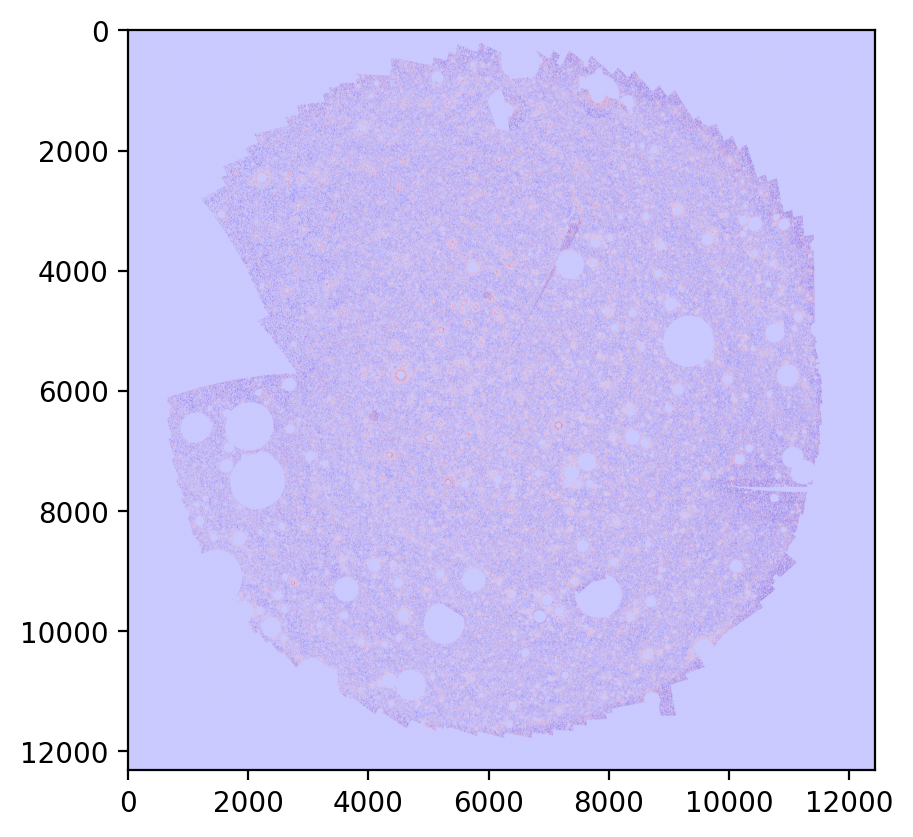

In [21]:
plt.imshow(mm.S, vmin=vmin, vmax=vmax, cmap='bwr')

In [24]:
# vmin, vmax = np.nanpercentile(cc.S[np.nonzero(cc.S)], [1, 99])
# plt.imshow(cc.S, vmin=vmin, vmax=vmax)

In [141]:
num_sky = np.prod(cc.ref_shape)

matrix = cc.A
n_cols = matrix.shape[1]
mask = np.ones(n_cols, dtype=bool)
mask[matrix.col] = False

target_mask = mask[num_sky + 1:]

empty_offsets_idx = np.where(target_mask)[0]

In [145]:
exp_idx = 4030
num_chunk = 860
offset_range = exp_idx * num_chunk, (exp_idx + 1) * num_chunk

In [ ]:
import numpy as np





In [15]:
cal_path = '/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det1_6p2arcsec/calibration/cal_D1_Ch10_17channels_5verticalbands_weighteddamping.h5'
mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration(cal_path)

  0%|                                                                                                                     | 0/13184 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 608228.52it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det1_6p2arcsec/calibration/cal_D1_Ch10_17channels_5verticalbands_weighteddamping.h5


In [5]:
partial_make_offset_map = partial(make_spherex_stripped_offset_map,
                                  chunk_valid_mask=chunk_valid_mask, 
                                  lvf_params=lvf_params, r_edges=r_edges, x_edges=x_edges, 
                                  tot_subchannels=172, num_columns=5)

In [6]:
cal_path = '/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_D4_Ch3_NumSub10_NumCh17_NumCol5.h5'
mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration(cal_path=cal_path)
# partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)
sc_sigma = 1.0
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=False, 
    chunk_map=grid_chunk_map, 
    det_valid_mask=chunk_valid_mask[grid_chunk_map], 
    max_workers=20,
    make_std_map=False, 
    apply_sigma_clipping=False,  
    sigma=sc_sigma,
    ignore_list=[21],
    oversample_factor=OVERSAMPLE_FACTOR,
    det_offset_func=partial_make_offset_map,#partial_make_offset_map,
    cache_batch_size=20,
    coadd_batch_size=100,
    cache_dir='/home/thomasli/spherex/selfcal/cache',
    cache_intermediate=False,
    det_aux=None
)

    # wav_mean, wav_std = wav_coadd(det_BC, det_BW, mean_map=maps['mean_map']['data'], std_map=maps['std_map']['data'], 
    #                               reproj_list=mm.reproj_list, cache_list=mm.cached_list, ref_shape=maps['mean_map']['data'].shape, 
    #                               sigma=sc_sigma, batch_size=40, max_workers=40)    

    # wav_mean_maps = {'data': wav_mean, 'unit': 'um'}
    # wav_std_maps = {'data': wav_std, 'unit': 'um'}
    # mm.append_maps({'wav_mean_map': wav_mean_maps, 'wav_std_map': wav_std_maps})

# mm.save_mosaic(mos_file=f'mosaic{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.fits', overwrite=True)

    # # Clear memory
    # del mm, maps
    # gc.collect()
    # t1 = time.time()
    # print(f"Finished channel {ch} for detector {DETECTOR} in {t1 - t0:.2f} seconds")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 582903.29it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_D4_Ch3_NumSub10_NumCh17_NumCol5.h5
Computing mean map...
Processing 13184 files in 132 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [26:47<00:00, 12.18s/it]


Mean map computation finished in 1608.13 seconds.


In [7]:
mosaic = mm.maps['mean_map']['data']

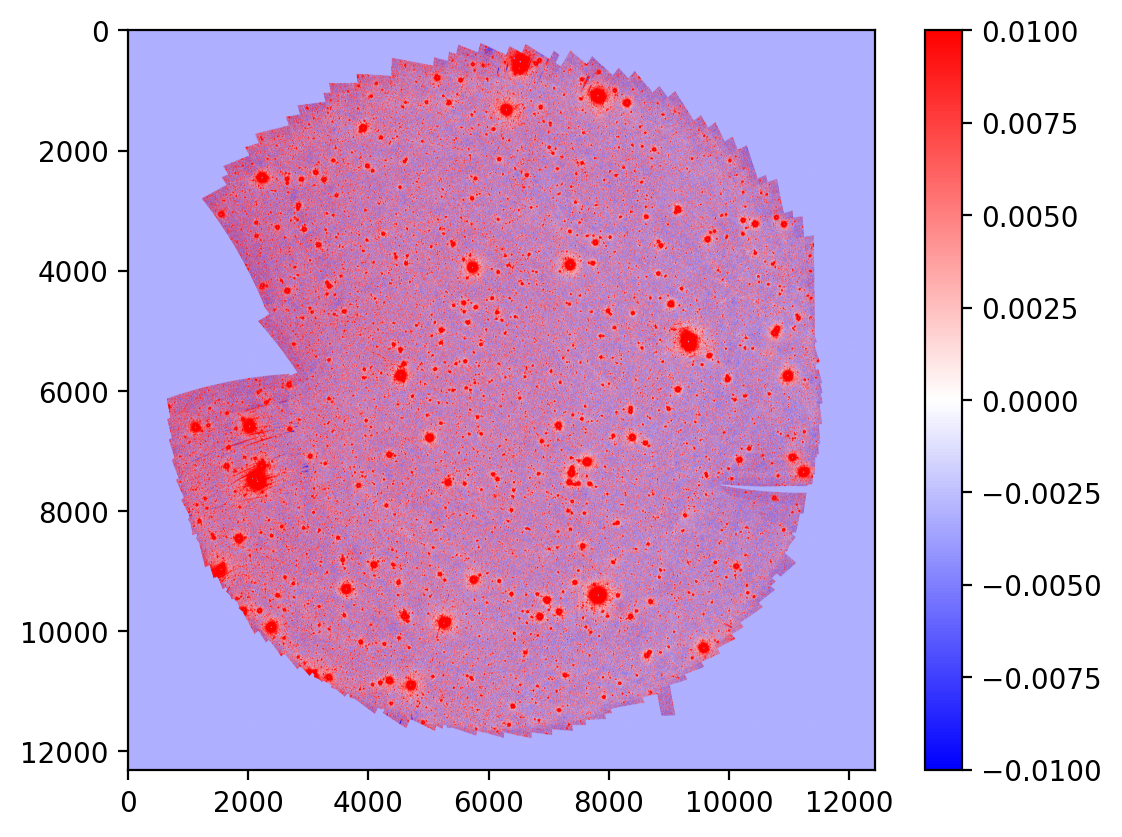

In [8]:
plt.imshow(mosaic-np.nanmedian(mosaic[np.nonzero(mosaic)]), vmin=-0.01, vmax=0.01, cmap='bwr')
plt.colorbar()

In [147]:
OO = cc.O[:,chunk_valid_mask.astype(bool)].reshape(4412, 12, 5)

In [148]:
plt.plot(OO[4030].T)

In [167]:
# vmin, vmax = np.percentile(mosaic[np.nonzero(mosaic)], [1, 99])+0.02
# plt.imshow(mosaic+0.02, norm=LogNorm(vmin=vmin, vmax=vmax))
# plt.colorbar()